In [14]:
import tensorflow as tf
import pandas as pd
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split

tf.keras.backend.set_floatx("float32")

SEED = 42 #A seed ensures reproducibility — using the same seed will make all random processes generate the same results every time the code runs.

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [15]:
import tensorflow as tf
import pandas as pd
import os
import random
import numpy as np
from sklearn.model_selection import train_test_split

tf.keras.backend.set_floatx("float32")

SEED = 42 #A seed ensures reproducibility — using the same seed will make all random processes generate the same results every time the code runs.

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

os.environ["CUDA_VISIBLE_DEVICES"] = ""

In [16]:
df = pd.read_excel("C:/Users/USER/Desktop/geopolymar/data/GPC_Dataset.xlsx")

feature_cols = [
    'FA/binder',
    'CA/Binder',
    'Binder (kg)',
    '% of SiO2',
    '% of CaO',
    '% of Al2O3',
    'liquid/binder ratio',
    'NaOH Molarity',
    'Na2SiO3/  NaOH',
    'Additional Water (%)',
    'SP (% of b)',
    'Curing temp (0 C)'
]

X = df[feature_cols].values.astype(np.float32)

# Time
t = df[['Age']].values.astype(np.float32)

# Target
y = df[['Comp. Strength (Mpa)']].values.astype(np.float32)

X_train, X_test, t_train, t_test, y_train, y_test = train_test_split(
    X, t, y, test_size=0.2, random_state=42
)

X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0) + 1e-6
t_mean, t_std = t_train.mean(), t_train.std() + 1e-6
y_mean, y_std = y_train.mean(), y_train.std() + 1e-6

# Normalize
X_train_n = (X_train - X_mean) / X_std
t_train_n = (t_train - t_mean) / t_std
y_train_n = (y_train - y_mean) / y_std

X_test_n = (X_test - X_mean) / X_std
t_test_n = (t_test - t_mean) / t_std
y_test_n = (y_test - y_mean) / y_std

In [17]:
class PINN(tf.keras.Model):
    def __init__(self):
        super().__init__()

        self.hidden = [
            tf.keras.layers.Dense(
                64, activation="tanh",
                kernel_regularizer=tf.keras.regularizers.l2(1e-1)
            ),
            # tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(
                64, activation="tanh", # tf.nn.swish
                kernel_regularizer=tf.keras.regularizers.l2(1e-1)
            ),
            # tf.keras.layers.Dropout(0.1),
            tf.keras.layers.Dense(
                32, activation="tanh",
                kernel_regularizer=tf.keras.regularizers.l2(1e-2)
            )
        ]

        # Outputs
        self.S_out = tf.keras.layers.Dense(1)
        self.Smax_out = tf.keras.layers.Dense(1)

        # Arrhenius parameters
        self.k0_out = tf.keras.layers.Dense(1)
        self.Ea_out = tf.keras.layers.Dense(1)

    def call(self, X, t):
        """
        Returns:
            S     : normalized strength
            Smax  : normalized ultimate strength
            k     : reaction rate (Arrhenius)
            k0    : pre-exponential factor
            Ea    : activation energy
        """

        z = tf.concat([X, t], axis=1)
        for layer in self.hidden:
            z = layer(z)

        # Strength predictions
        S = self.S_out(z)
        Smax = self.Smax_out(X)

        # Arrhenius parameters (positive)
        k0 = tf.nn.softplus(self.k0_out(z))
        Ea = tf.nn.softplus(self.Ea_out(z))

        # Temperature (last feature)
        T_c = X[:, -1:]                             # normalized 
        T = T_c * X_std[-1] + X_mean[-1] + 273.15   # Kelvin

        R = 8.314  # J/mol/K

        # Arrhenius rate
        k = k0 * tf.exp(-Ea / (R * T))

        return S, Smax, k, k0, Ea


In [18]:
@tf.function
def pinn_loss(model, X, t, y):
    R = 8.314  # J/mol/K

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)

        # Forward pass
        S, Smax, k, k0, Ea = model(X, t)

        # Time derivative
        dS_dt = tape.gradient(S, t)#used AD to calculted the predicted derivative

        # Data loss
        data_loss = tf.reduce_mean(tf.square(S - y))

        # Physics loss (ODE)
        ode_residual = dS_dt - k * (Smax - S) #last portion is physics based
        physics_loss = tf.reduce_mean(tf.square(ode_residual))

        # Monotonicity constraint
        mono_loss = tf.reduce_mean(tf.nn.relu(-dS_dt))

        # Upper bound constraint
        bound_loss = tf.reduce_mean(tf.nn.relu(S - Smax))

        # Arrhenius regularization
        arrhenius_reg = (
            1e-4 * tf.reduce_mean(tf.square(k0)) +
            1e-6 * tf.reduce_mean(tf.square(Ea))
        )

        # Total loss
        total_loss = (
            data_loss
            + 1.0 * physics_loss
            + 0.1 * mono_loss
            + 0.1 * bound_loss
            + arrhenius_reg
        )

    return (
        total_loss,
        data_loss,
        physics_loss,
        mono_loss,
        bound_loss,
        arrhenius_reg
    )

In [19]:
model = PINN()
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

X_train_tf = tf.convert_to_tensor(X_train_n, dtype=tf.float32)
t_train_tf = tf.convert_to_tensor(t_train_n, dtype=tf.float32)
y_train_tf = tf.convert_to_tensor(y_train_n, dtype=tf.float32)

X_test_tf = tf.convert_to_tensor(X_test_n, dtype=tf.float32)
t_test_tf = tf.convert_to_tensor(t_test_n, dtype=tf.float32)
y_test_tf = tf.convert_to_tensor(y_test_n, dtype=tf.float32)

loss_history = {
    "total": [],
    "data": [],
    "physics": [],
    "monotonicity": [],
    "bound": [],
    "arrhenius": []
}

EPOCHS = 5001

for epoch in range(EPOCHS):
    with tf.GradientTape() as tape:
        (
            loss,
            d_loss,
            p_loss,
            mono_loss,
            bound_loss,
            arr_loss
        ) = pinn_loss(model, X_train_tf, t_train_tf, y_train_tf)

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    loss_history["total"].append(loss.numpy())
    loss_history["data"].append(d_loss.numpy())
    loss_history["physics"].append(p_loss.numpy())
    loss_history["monotonicity"].append(mono_loss.numpy())
    loss_history["bound"].append(bound_loss.numpy())
    loss_history["arrhenius"].append(arr_loss.numpy())

    if epoch % 500 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total {loss.numpy():.3e} | "
            f"Data {d_loss.numpy():.3e} | "
            f"Phys {p_loss.numpy():.3e} | "
            f"Arr {arr_loss.numpy():.3e}"
        )

Epoch     0 | Total 3.562e+00 | Data 1.333e+00 | Phys 2.169e+00 | Arr 6.569e-05
Epoch   500 | Total 3.020e-01 | Data 2.195e-01 | Phys 4.910e-02 | Arr 1.018e-05
Epoch  1000 | Total 1.975e-01 | Data 1.397e-01 | Phys 3.634e-02 | Arr 3.249e-05
Epoch  1500 | Total 1.113e-01 | Data 8.594e-02 | Phys 1.109e-02 | Arr 5.208e-05
Epoch  2000 | Total 6.511e-02 | Data 5.050e-02 | Phys 6.291e-03 | Arr 6.662e-05
Epoch  2500 | Total 2.833e-02 | Data 2.130e-02 | Phys 3.238e-03 | Arr 8.807e-05
Epoch  3000 | Total 1.933e-02 | Data 1.455e-02 | Phys 2.932e-03 | Arr 9.510e-05
Epoch  3500 | Total 1.463e-02 | Data 1.202e-02 | Phys 1.397e-03 | Arr 9.098e-05
Epoch  4000 | Total 1.338e-02 | Data 1.099e-02 | Phys 1.577e-03 | Arr 8.630e-05
Epoch  4500 | Total 1.136e-02 | Data 9.935e-03 | Phys 9.073e-04 | Arr 8.246e-05
Epoch  5000 | Total 1.102e-02 | Data 9.417e-03 | Phys 1.241e-03 | Arr 7.841e-05


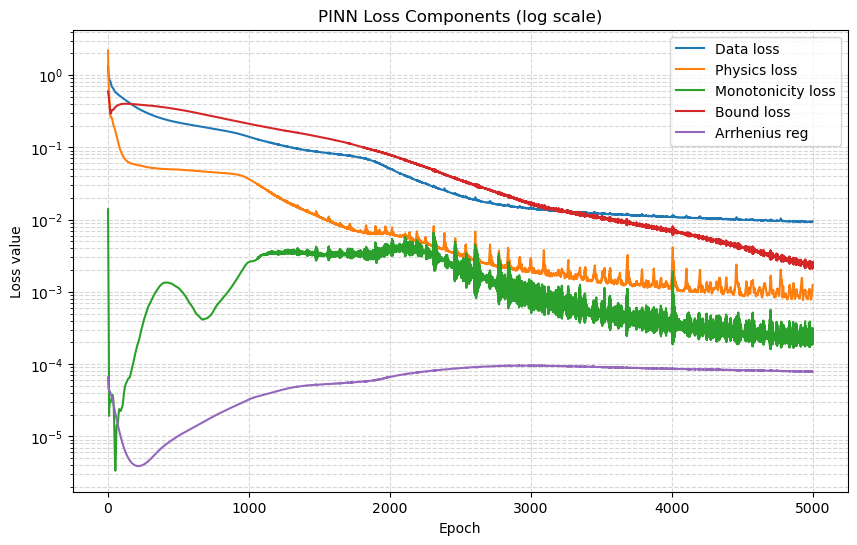

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(loss_history["data"], label="Data loss")
plt.plot(loss_history["physics"], label="Physics loss")
plt.plot(loss_history["monotonicity"], label="Monotonicity loss")
plt.plot(loss_history["bound"], label="Bound loss")
plt.plot(loss_history["arrhenius"], label="Arrhenius reg")

plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Loss value")
plt.title("PINN Loss Components (log scale)")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()


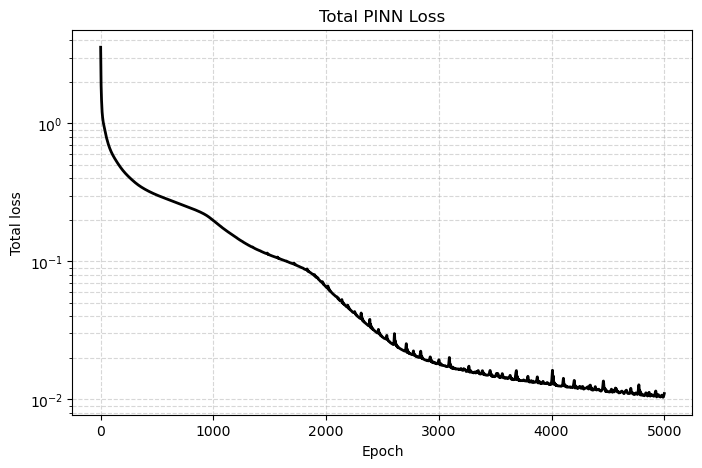

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(loss_history["total"], color="black", linewidth=2)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("Total loss")
plt.title("Total PINN Loss")
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.show()


In [22]:
def predict_strength(model, X, t):
    # Normalize using training statistics
    Xn = (X - X_mean) / X_std
    tn = (t - t_mean) / t_std

    # Forward pass
    S, _, _, _, _ = model(
        tf.convert_to_tensor(Xn, dtype=tf.float32),
        tf.convert_to_tensor(tn, dtype=tf.float32)
    )

    # Denormalize output
    return S.numpy() * y_std + y_mean


In [23]:
y_train_pred = predict_strength(model, X_train, t_train)

y_test_pred = predict_strength(model, X_test, t_test)

In [24]:
y_train_true = y_train.flatten()
y_train_pred = y_train_pred.flatten()

y_test_true = y_test.flatten()
y_test_pred = y_test_pred.flatten()


In [25]:
from sklearn.metrics import r2_score, mean_squared_error

r2_train = r2_score(y_train_true, y_train_pred)
mse_train = mean_squared_error(y_train_true, y_train_pred)
rmse_train = np.sqrt(mse_train)

r2_test = r2_score(y_test_true, y_test_pred)
mse_test = mean_squared_error(y_test_true, y_test_pred)
rmse_test = np.sqrt(mse_test)

print("Training Metrics")
print(f"R²   : {r2_train:.2f}")
print(f"MSE  : {mse_train:.2f}")
print(f"RMSE : {rmse_train:.2f} MPa\n")

print("Test Metrics")
print(f"R²   : {r2_test:.2f}")
print(f"MSE  : {mse_test:.2f}")
print(f"RMSE : {rmse_test:.2f} MPa")


Training Metrics
R²   : 0.99
MSE  : 2.46
RMSE : 1.57 MPa

Test Metrics
R²   : 0.94
MSE  : 16.87
RMSE : 4.11 MPa


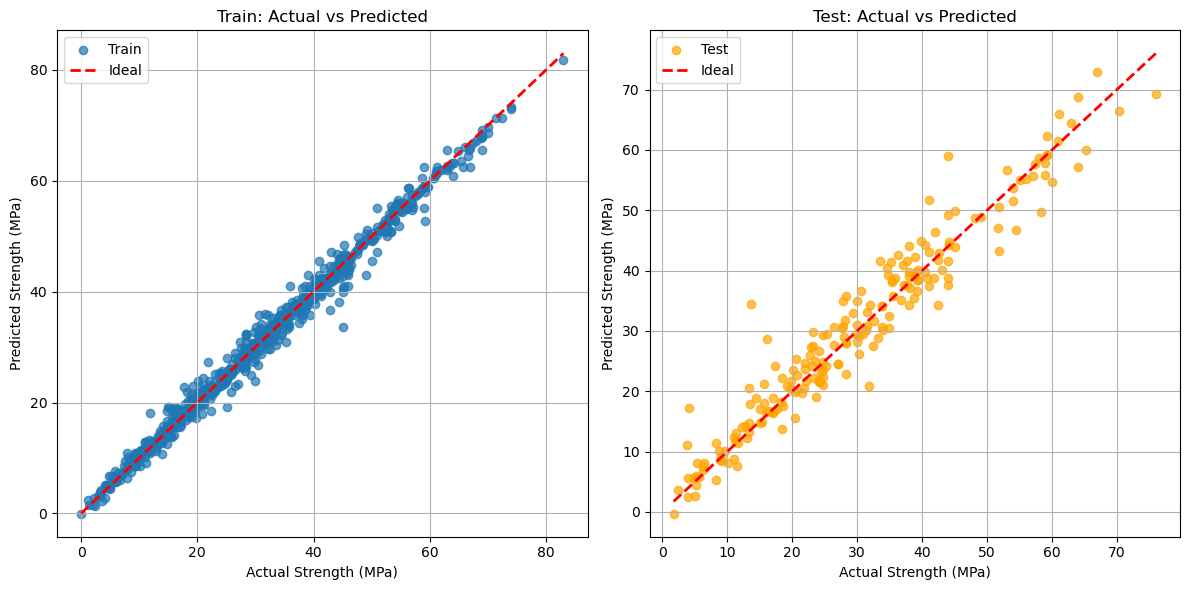

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_train_true, y_train_pred, alpha=0.7, label='Train')
plt.plot(
    [y_train_true.min(), y_train_true.max()],
    [y_train_true.min(), y_train_true.max()],
    'r--', linewidth=2, label='Ideal'
)
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Train: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(y_test_true, y_test_pred, alpha=0.7, color='orange', label='Test')
plt.plot(
    [y_test_true.min(), y_test_true.max()],
    [y_test_true.min(), y_test_true.max()],
    'r--', linewidth=2, label='Ideal'
)
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.title("Test: Actual vs Predicted")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


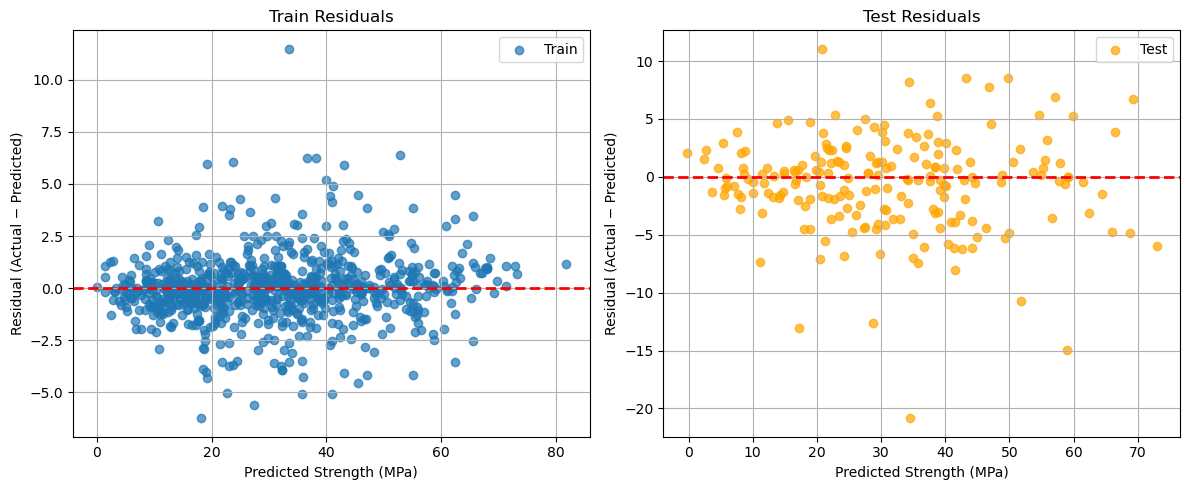

In [27]:
plt.figure(figsize=(12, 5))

# residuals
residuals_train = y_train_true - y_train_pred
residuals_test = y_test_true - y_test_pred

plt.subplot(1, 2, 1)
plt.scatter(y_train_pred, residuals_train, alpha=0.7, label='Train')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Train Residuals")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(y_test_pred, residuals_test, alpha=0.7, color='orange', label='Test')
plt.axhline(0, color='r', linestyle='--', linewidth=2)
plt.xlabel("Predicted Strength (MPa)")
plt.ylabel("Residual (Actual − Predicted)")
plt.title("Test Residuals")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
